In [1]:
import scipy
import sys
from skimage import io
import numpy as np
import numpy.matlib
import matplotlib
import skimage
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd
from numpy import matlib
import seaborn as sns
import math
import os
import scipy.optimize
import scipy.io as sio
from scipy import stats
import scipy.ndimage
from scipy.interpolate import make_smoothing_spline
from pathlib import Path

sns.set(font_scale=1.5)
sns.set_style("whitegrid")

In [6]:
# Experiment specifics
base_path="/Volumes/data_ssd2/Rojas_Lab/data"
expt_id="/250519_TEM"
conds=["/1_HPF_A2343", "/5_HPF_A2352"]
threshs=(255.0-np.array([43,60]))/255.0
bkgds=(255.0-np.array([160,170]))/255.0


# Parameters
scale=500.0/762.0 # nm/pixel.
depth=200
opp_depth=int(10/scale) # distance in nm to backtrack — allows you to precisely measure the position of the membrane
window=9
min_depth=100 # minimum depth for us to consider a cross-section for analysis
cutoff_length=int(opp_depth+min_depth/scale)
cutoff=0.2 # Peak prominence cutoff for "membrane" detection
offset_ind=int(30/scale)
# num_fits=40
rel_val=0.7
spacing=4.0 # spacing in pixels between adjacent fits
out_dir='saved_contours' #or 'trace'

col=['Condition', 'Cell number', 'Thickness (nm)']
cell_thickness_df=pd.DataFrame(columns=col)

contours=[]

for cond_ind in range(len(conds)):
    # Navigate to a specific condition
    contours.append([])
    cond=conds[cond_ind]
    bkgd=bkgds[cond_ind]
    peak_val=threshs[cond_ind]
    dirs = [item.name for item in Path(base_path+expt_id+'/'+out_dir+cond).iterdir() if item.is_dir() and item.name!='plots']
    # Work through all images from that condition
    cell_count=0
    for temp_dir in dirs:
        print(temp_dir)
        im1=io.imread(base_path+expt_id+cond+'/'+temp_dir+'.tif')
        im2=im1[:,:]
        # Plotting data
        sns.set_style('white')
        fig=plt.figure(figsize=[10,10])
        plt.imshow(im1)
        # Work through all traces from that image
        cell_traces_list= [item.name for item in Path(base_path+expt_id+'/'+out_dir+cond+'/'+temp_dir).glob(temp_dir+'*.csv')]
        for name in cell_traces_list:
            print(name)
            coords=pd.read_csv(base_path+expt_id+'/'+out_dir+cond+'/'+temp_dir+'/'+name)
            xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
            lam=10
            if len(xv)<5: # We need to have additional points to make a spline of this sort
                xv1,yv1=np.copy(xv),np.copy(yv)
                while len(xv1)<5:
                    xv1,yv1=xv1[np.argsort(xv1)],yv1[np.argsort(xv1)]
                    temp_x,temp_y=np.mean(xv1[:2]),np.mean(yv1[:2])
                    xv1,yv1=np.append(xv1,temp_x),np.append(yv1,temp_y)
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv1[np.argsort(xv1)], yv1[np.argsort(xv1)], lam=lam)
            else:
                # Fit a spline to the trace points
                spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
            xnew = np.arange(np.amin(xv), np.amax(xv), spacing)[1:-1]
            xnew1 = np.arange(np.amin(xv), np.amax(xv), spacing/10.0)
            ynew1=spl(xnew1)
            intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
            # Plotting spline values
            plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
            # Calculate intensity along transverse slices
            slopes=[]
            for ind in np.arange(len(xnew)):
                point=np.nonzero(xnew1>xnew[ind])[0][0]
                slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
                slopes.append(slope)
                num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
                xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
                xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
                yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
                # now let's unit-spaced coordinates along this line, from start to end.
                dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
                xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                sel_vals=np.nonzero((xcoords>=0)*(xcoords<=im1.shape[1])*(ycoords>=0)*(ycoords<=im1.shape[0]))
                if len(sel_vals[0])>cutoff_length:
                    intensity_vals[ind,sel_vals]=(255.0-im2[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)])/255.0
    
            # Let's just take the average over the first 30nm and find the first point where this intensity drops by 1/2 the difference 
            # between the peak 
            final_inds=[]
            for temp_int in range(intensity_vals.shape[0]):
                if np.sum(np.isnan(intensity_vals[temp_int,:]))<intensity_vals.shape[1]:
                    signal=intensity_vals[temp_int,offset_ind:]

                    
                    # peak_val=np.nanmean(intensity_vals[temp_int,:offset_ind])
                    if np.sum(signal<(peak_val-0.5*(peak_val-bkgd)))>0:
                        final_inds.append(np.nonzero(signal<(peak_val-0.5*(peak_val-bkgd)))[0][0]+offset_ind)
                    else:
                        final_inds.append(np.nan)
                else:
                    final_inds.append(np.nan)

            contours[-1].append([np.nanmean(intensity_vals,axis=0)]) # after the fact we will go back and take the relevant averages
                    
            for ind in np.arange(len(xnew)):
                if ~np.isnan(final_inds[ind]):
                    xs=np.sign(xv[-1]-xv[0])*np.sign(slopes[ind][0]) # determines whether x should increase or decrease.
                    yrange=float(spl(xnew1[point]))-1.0/slopes[ind][0]*(xrange-xnew1[point])
                    # now let's unit-spaced coordinates along this line, from start to end.
                    dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slopes[ind][0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slopes[ind][0]))
                    xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
                    temp_xcoords=[xcoords[opp_depth],xcoords[final_inds[ind]]]
                    temp_ycoords=[ycoords[opp_depth],ycoords[final_inds[ind]]]
                    plt.plot(temp_xcoords,temp_ycoords,'-',color='g',alpha=0.6)
                    temp_df=pd.DataFrame(columns=col,data=[[cond[1:],cell_count,scale*(final_inds[ind]-opp_depth)]])
                    cell_thickness_df=pd.concat([cell_thickness_df,temp_df])
            cell_count+=1
        if not(os.path.isdir(base_path+expt_id+'/'+out_dir+cond+'/plots')):
            os.mkdir(base_path+expt_id+'/'+out_dir+cond+'/plots')
        fig.savefig(base_path+expt_id+'/'+out_dir+cond+'/plots/'+temp_dir+'.png',bbox_inches='tight',dpi=150)
        plt.close()

1_HPF_10kX_0003
1_HPF_10kX_0003_cell_1.csv
1_HPF_10kX_0004
1_HPF_10kX_0004_cell_1.csv
1_HPF_10kX_0006
1_HPF_10kX_0006_cell_1.csv
1_HPF_10kX_0007
1_HPF_10kX_0007_cell_1.csv
1_HPF_10kX_0008
1_HPF_10kX_0008_cell_1.csv
1_HPF_10kX_0009
1_HPF_10kX_0009_cell_1.csv
1_HPF_10kX_0010
1_HPF_10kX_0010_cell_1.csv
1_HPF_10kX_0011
1_HPF_10kX_0011_cell_1.csv
1_HPF_10kX_0012
1_HPF_10kX_0012_cell_1.csv
1_HPF_10kX_0013
1_HPF_10kX_0013_cell_1.csv
1_HPF_10kX_0014
1_HPF_10kX_0014_cell_1.csv
1_HPF_10kX_0016
1_HPF_10kX_0016_cell_1.csv
1_HPF_10kX_0017
1_HPF_10kX_0017_cell_1.csv
1_HPF_10kX_0018
1_HPF_10kX_0018_cell_1.csv
1_HPF_10kX_0019
1_HPF_10kX_0019_cell_1.csv
5_HPF_10kX_0002
5_HPF_10kX_0002_cell_1.csv
5_HPF_10kX_0003
5_HPF_10kX_0003_cell_1.csv
5_HPF_10kX_0004
5_HPF_10kX_0004_cell_1.csv
5_HPF_10kX_0005
5_HPF_10kX_0005_cell_1.csv
5_HPF_10kX_0006
5_HPF_10kX_0006_cell_1.csv
5_HPF_10kX_0007
5_HPF_10kX_0007_cell_1.csv
5_HPF_10kX_0009
5_HPF_10kX_0009_cell_1.csv
5_HPF_10kX_0010
5_HPF_10kX_0010_cell_1.csv


/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_85279/3307909611.py:102: RuntimeWarning: Mean of empty slice
  contours[-1].append([np.nanmean(intensity_vals,axis=0)]) # after the fact we will go back and take the relevant averages


5_HPF_10kX_0011
5_HPF_10kX_0011_cell_1.csv
5_HPF_10kX_0012
5_HPF_10kX_0012_cell_1.csv
5_HPF_10kX_0013
5_HPF_10kX_0013_cell_1.csv
5_HPF_10kX_0014
5_HPF_10kX_0014_cell_1.csv
5_HPF_10kX_0016
5_HPF_10kX_0016_cell_1.csv
5_HPF_10kX_0018
5_HPF_10kX_0018_cell_1.csv
5_HPF_10kX_0019
5_HPF_10kX_0019_cell_1.csv
5_HPF_10kX_0020
5_HPF_10kX_0020_cell_1.csv


([0, 1], [Text(0, 0, '1_HPF_A2343'), Text(1, 0, '5_HPF_A2352')])

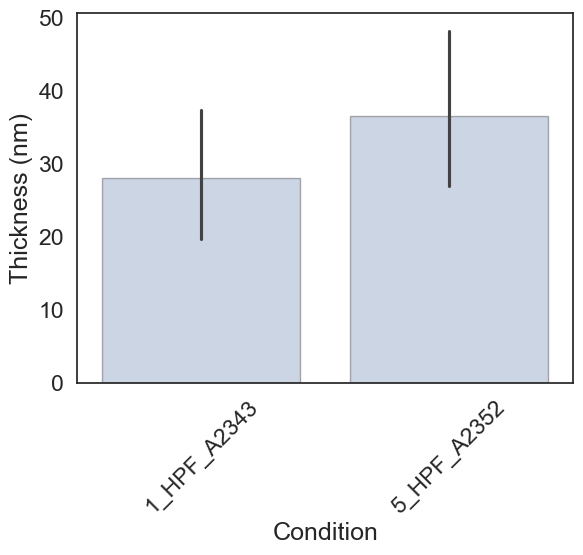

In [7]:
temp_df_out=cell_thickness_df.groupby(['Condition','Cell number'])['Thickness (nm)'].median().reset_index()
plot = sns.barplot(x='Condition', y='Thickness (nm)', data=temp_df_out, edgecolor='black', linewidth=1, native_scale=True, alpha=0.3, legend=False)
plt.xticks(rotation=45)

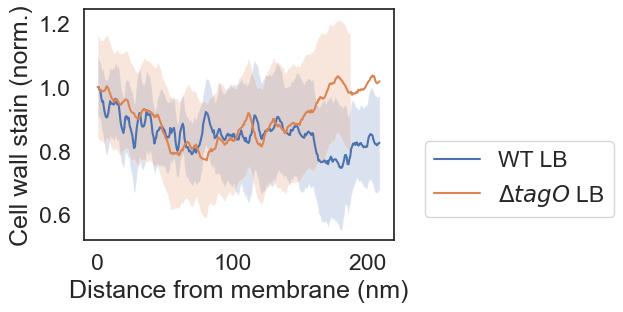

In [8]:
int_conts_ls=[]
fig=plt.figure(figsize=[4,3])
x=scale*np.arange(0,int(depth/scale)+opp_depth,1)
cutoff_num=2
cond_plotting=["/1_HPF_A2343", "/5_HPF_A2352"]
cond_labels =["WT LB", r"$\Delta tagO$ LB"]
for cond in cond_plotting:
    ind=conds.index(cond)
    int_conts=np.nan*np.ones([len(contours[ind]),int(depth/scale)+opp_depth])
    for ind1 in range(len(contours[ind])):
        int_conts[ind1,:]=np.asarray(contours[ind][ind1])
    temp_v1=(np.sum(~np.isnan(int_conts),axis=0)<cutoff_num)
    for ind2 in range(int_conts.shape[1]):
        if temp_v1[ind2]:
            int_conts[:,ind2]=np.nan
    
        # if np.sum(~np.isnan(int_conts[:,ind2])<cutoff_num):
        #     int_conts[:,ind2]=np.nan*np.ones(int_conts.shape[0])
    int_conts_ls.append(int_conts)

    med=np.nanmedian(int_conts_ls[-1],axis=0)
    sel_vals=np.nonzero(~np.isnan(med))
    iqr=scipy.stats.iqr(int_conts_ls[-1],axis=0)
    med*=1.0/med[0]
    iqr*=1.0/med[0]
    med=med[sel_vals]
    iqr=iqr[sel_vals]
    plt.plot(x[sel_vals],med,label=cond_labels[cond_plotting.index(cond)])
    plt.fill_between(x[sel_vals],med+iqr/2.0,med-iqr/2.0,alpha=0.2)
plt.legend(loc=[1.1,0.1])
plt.xlabel('Distance from membrane (nm)')
plt.ylabel('Cell wall stain (norm.)')
fig.savefig(base_path+expt_id+'/wall_profile_norm.png',dpi=300,bbox_inches='tight')
plt.show()


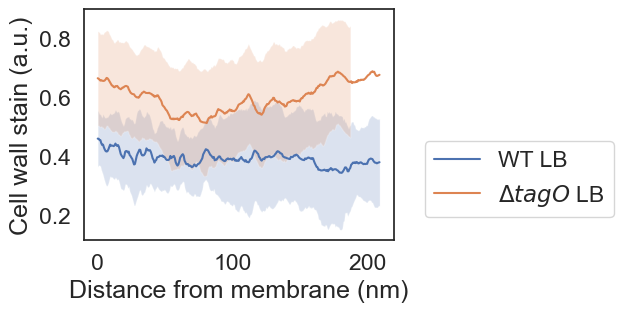

In [9]:
int_conts_ls=[]
fig=plt.figure(figsize=[4,3])
x=scale*np.arange(0,int(depth/scale)+opp_depth,1)
cutoff_num=2
cond_plotting=["/1_HPF_A2343", "/5_HPF_A2352"]
cond_labels =["WT LB", r"$\Delta tagO$ LB"]
for cond in cond_plotting:
    ind=conds.index(cond)
    int_conts=np.nan*np.ones([len(contours[ind]),int(depth/scale)+opp_depth])
    for ind1 in range(len(contours[ind])):
        int_conts[ind1,:]=np.asarray(contours[ind][ind1])
    temp_v1=(np.sum(~np.isnan(int_conts),axis=0)<cutoff_num)
    for ind2 in range(int_conts.shape[1]):
        if temp_v1[ind2]:
            int_conts[:,ind2]=np.nan
    
        # if np.sum(~np.isnan(int_conts[:,ind2])<cutoff_num):
        #     int_conts[:,ind2]=np.nan*np.ones(int_conts.shape[0])
    int_conts_ls.append(int_conts)

    med=np.nanmedian(int_conts_ls[-1],axis=0)
    sel_vals=np.nonzero(~np.isnan(med))
    iqr=scipy.stats.iqr(int_conts_ls[-1],axis=0)
    # med*=1.0/med[0]
    # iqr*=1.0/med[0]
    med=med[sel_vals]
    iqr=iqr[sel_vals]
    plt.plot(x[sel_vals],med,label=cond_labels[cond_plotting.index(cond)])
    plt.fill_between(x[sel_vals],med+iqr/2.0,med-iqr/2.0,alpha=0.2)
plt.legend(loc=[1.1,0.1])
plt.xlabel('Distance from membrane (nm)')
plt.ylabel('Cell wall stain (a.u.)')
fig.savefig(base_path+expt_id+'/wall_profile.png',dpi=300,bbox_inches='tight')
plt.show()
